# Decompose the +0.676 gap · risk-coverage · H1–H4 multiplicity re-analysis

**Pure re-analysis EVALUATION** (zero LLM spend, `numpy`+`scipy` only) over three iter-2
experiment outputs of the *No-Derivation-No-Relation* closure-certificate project:

* **showdown** (`art_N0e4pH_C_Cxw`) — Mode-A vs PoT/SC/naive leaderboards on synthetic QCN.
* **channel** (`art_FtN4LBzazO_l`) — calibrated synthetic reader channel (per-recall-slice trends).
* **real-text** (`art_fil2iJ6xSrYx`) — NarrativeTime + TDDMan hallucination / risk-coverage.

The script loads the three `method_out.json` files and **recomputes / reorganises statistics**
into three tasks:

| Task | What it does | Retires |
|---|---|---|
| **1 · Decomposition** | splits the Mode-A-vs-PoT system gap additively into an **INHERITED** (exact-table-vs-LLM) component and a **NOVEL** iteration component, separating the *selective-accuracy* axis from the *coverage* axis | "central claim conflates two effects" (MAJOR) |
| **2 · Risk-coverage** | re-presents the real-text hallucination result as a risk-coverage operating point, with the ~90% abstention rate always stated alongside | "hallucination driven by abstention" (MINOR) |
| **3 · Multiplicity** | formalises the confirmatory family {H1,H2,H3,H4} under Holm-Bonferroni + hierarchical gatekeeping | — |

**Headline result (reproduced exactly below):** Allen bite-pool system gap
**+0.676 = inherited +0.673 + novel +0.0025** (additivity residual 0.000). The genuine
iteration novelty lives on the *coverage* axis, not the selective-accuracy axis.

---
### Demo note on data scale
`mini_demo_data.json` carries the **full pre-aggregated metadata** of all three sources
(so every leaderboard-derived headline number is **exact**) plus a **curated 6-rows-per-cell
subset** of the showdown per-network rows. The selective-accuracy decomposition, risk-coverage,
and multiplicity numbers reproduce exactly; the *coverage-axis* gaps are **recomputed on the tiny
subset** and therefore only approximate the full-data published values (4 of the 17 sanity checks
flag this, as expected — see the Run section).

In [1]:
# Install dependencies (works on Colab AND local Jupyter).
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.2')

# numpy / scipy / matplotlib — pre-installed on Colab; install locally at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import gc
import json
import math
import sys
from pathlib import Path

import numpy as np
from loguru import logger
from scipy import stats
import matplotlib.pyplot as plt

# numpy 2.0 compat shims (harmless if the attribute already exists)
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "product"): np.product = np.prod

# Logging to stdout. (The original script also wrote logs/run.log; dropped here so the
# notebook needs no logs/ directory — this is the only change to the logging setup.)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

WS = Path(".").resolve()   # output dir (eval_out.json / eval_digest.md) = notebook cwd

In [3]:
# Load the curated demo data from GitHub (Colab) with a local-file fallback.
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-3/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded sources:", list(data.keys()))
for _name in data:
    _md = data[_name].get("metadata", {})
    _ds = data[_name].get("datasets", [])
    print(f"  {_name:9s}: metadata_keys={len(_md):<3} "
          f"datasets={[(x['dataset'], len(x['examples'])) for x in _ds]}")

Loaded sources: ['showdown', 'channel', 'realtext']
  showdown : metadata_keys=9   datasets=[('synthetic_qcn_point', 48), ('synthetic_qcn_allen', 48)]
  channel  : metadata_keys=1   datasets=[]
  realtext : metadata_keys=23  datasets=[('narrativetime', 5), ('tddman', 5)]


## Configuration

This re-analysis is pure `numpy`+`scipy`; the only runtime knob is the **paired-bootstrap
resample count** `BOOT_B`. The whole pipeline runs in well under a second on the demo subset,
so the original `BOOT_B = 10000` fits comfortably — we start smaller and scale up.

In [5]:
# ------------------------------- CONFIG ------------------------------- #
SEED = 20260617          # fixed seed (original)

# Paired-bootstrap resamples. Start small for the demo; original value is 10000.
BOOT_B = 10000           # original full value (runs in <1s on the demo subset)
# BOOT_B = 2000          # smaller/faster alternative

# Use only the first N per-network rows per algebra (0 = all rows in the demo subset).
# Mirrors the original CLI `python eval.py 200`.
LIMIT_EXAMPLES = 0

print(f"SEED={SEED}  BOOT_B={BOOT_B}  LIMIT_EXAMPLES={LIMIT_EXAMPLES or 'ALL (demo subset)'}")

SEED=20260617  BOOT_B=10000  LIMIT_EXAMPLES=ALL (demo subset)


## Generic helpers

`load_source` returns one source block from the loaded `data` dict (the original read
`full_method_out.json` from disk). `sanitize`/`fnum` make the output strict-valid JSON
(NaN/Inf → `null`). `paired_bootstrap_mean_diff`, `jonckheere_terpstra`, and
`spearman_on_cells` are the statistical primitives, copied verbatim from the original script.

In [6]:
def load_source(name: str) -> tuple[dict, str]:
    """Return (block, variant) for one source, reading from the loaded `data` dict.

    The original read full_method_out.json from disk; here it is the curated demo subset.
    """
    return data[name], "mini_demo_data.json"


def sanitize(obj):
    """Recursively convert NaN/Inf to None so output is strict-valid JSON."""
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize(v) for v in obj]
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return None if (math.isnan(v) or math.isinf(v)) else v
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

def fnum(x):
    """Coerce to float, NaN/None-safe."""
    try:
        v = float(x)
        return v
    except (TypeError, ValueError):
        return float("nan")

def paired_bootstrap_mean_diff(diff: np.ndarray, rng: np.random.Generator,
                               b: int = BOOT_B):
    """Bootstrap the mean of a per-unit difference array.

    Returns (point_estimate, ci95 [2.5,97.5], ci_m2 [1.25,98.75], ci_m3 [0.833,99.167],
    p_one_sided_le_0).
    """
    diff = np.asarray(diff, dtype=float)
    n = diff.size
    point = float(diff.mean()) if n else float("nan")
    if n == 0:
        nan2 = [float("nan"), float("nan")]
        return point, nan2, nan2, nan2, float("nan")
    idx = rng.integers(0, n, size=(b, n))
    boot = diff[idx].mean(axis=1)
    ci95 = [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))]
    ci_m2 = [float(np.percentile(boot, 1.25)), float(np.percentile(boot, 98.75))]
    ci_m3 = [float(np.percentile(boot, 0.8333)), float(np.percentile(boot, 99.1667))]
    # one-sided p that the true mean diff <= 0 (fraction of boot <= 0)
    p_le0 = float(np.mean(boot <= 0.0))
    return point, ci95, ci_m2, ci_m3, p_le0

def jonckheere_terpstra(groups: list[np.ndarray]):
    """Jonckheere-Terpstra trend test for ordered groups (increasing alternative).

    Returns dict with J, E[J], Var[J], z, one-sided p (increasing trend).
    """
    groups = [np.asarray(g, dtype=float) for g in groups if len(g) > 0]
    k = len(groups)
    if k < 2:
        return {"J": None, "z": None, "p": None, "note": "fewer than 2 nonempty groups"}
    jt = 0.0
    for i in range(k):
        for j in range(i + 1, k):
            a, b = groups[i], groups[j]
            for x in a:
                jt += np.sum(b > x) + 0.5 * np.sum(b == x)
    ns = [len(g) for g in groups]
    N = sum(ns)
    e_j = (N**2 - sum(n**2 for n in ns)) / 4.0
    var_j = (N**2 * (2 * N + 3) - sum(n**2 * (2 * n + 3) for n in ns)) / 72.0
    z = (jt - e_j) / math.sqrt(var_j) if var_j > 0 else float("nan")
    p = float(stats.norm.sf(z)) if not math.isnan(z) else float("nan")
    return {"J": float(jt), "E_J": float(e_j), "Var_J": float(var_j),
            "z": float(z), "p_one_sided_increasing": p}

def spearman_on_cells(cells_in_order: list[float]):
    """Spearman rho of a per-bin value series vs bin order (monotone trend)."""
    y = np.asarray(cells_in_order, dtype=float)
    x = np.arange(len(y), dtype=float)
    if len(y) < 3 or np.allclose(y, y[0]):
        rho, p = (0.0, 1.0)
    else:
        rho, p = stats.spearmanr(x, y)
    return {"spearman_rho": float(rho), "spearman_p": float(p), "n_bins": int(len(y))}

## Task 1 — Decomposition

`decompose_algebra` does the load-bearing split, per algebra and per pool:

* **Selective-accuracy axis** (reused from the leaderboard aggregates → **exact**):
  `system_gap = SelAcc(modeA) − SelAcc(pot)` is split into
  `inherited = SelAcc(naive) − SelAcc(pot)` (exact-table-vs-LLM composition) and
  `novel_selacc = SelAcc(modeA) − SelAcc(naive)` (iteration on the selective-accuracy axis),
  with the additivity residual checked to ≈0.
* **Coverage / resolution axis** (recomputed per cell from the per-network rows): the
  full-minus-naive resolve-to-correct gap by hop length and by cyclomatic number, with
  paired-bootstrap CIs and Jonckheere/Spearman trend tests.

`crosssource_recall_slices` carries the channel's per-recall-slice corroboration and the
corrected Page-p note.

In [7]:
def build_per_network(ds_examples: list[dict], limit: int = 0):
    """Build per-network arrays grouped by metadata_cell for one algebra."""
    if limit:
        ds_examples = ds_examples[:limit]
    rows = []
    for e in ds_examples:
        gold = e.get("output")
        rows.append({
            "cell": e.get("metadata_cell"),
            "cyclomatic": e.get("metadata_cyclomatic"),
            "contributing_edges": e.get("metadata_contributing_edges"),
            "num_simple_paths": e.get("metadata_num_simple_paths"),
            "modeA_covered": bool(e.get("metadata_modeA_covered")),
            "naive_covered": bool(e.get("metadata_naive_covered")),
            "gold": gold,
            "full_correct": int(e.get("predict_modeA") == gold and gold is not None),
            "naive_correct": int(e.get("predict_naive") == gold and gold is not None),
            "predict_modeA": e.get("predict_modeA"),
            "predict_naive": e.get("predict_naive"),
            "predict_pot": e.get("predict_pot"),
        })
    return rows

def natural_selacc(rows, pred_key):
    """Selective accuracy at NATURAL coverage = mean over non-ABSTAIN of correctness."""
    answered = [r for r in rows if r[pred_key] not in (None, "ABSTAIN")]
    if not answered:
        return float("nan"), 0
    correct = sum(1 for r in answered if r[pred_key] == r["gold"])
    return correct / len(answered), len(answered)

def decompose_algebra(alg_block: dict, rows: list[dict], rng: np.random.Generator,
                      algebra: str) -> dict:
    """Full per-algebra decomposition on BOTH pools + coverage axis from per-network."""
    out = {"algebra": algebra}

    # ---- (A) SELECTIVE-ACCURACY axis, both pools (reuse leaderboard) ---- #
    pools = {}
    for pool_key, pool_name in [("H1_bite_bearing_pool", "bite_bearing"),
                                ("H1_all_comparison_pool", "all_comparison")]:
        lb = alg_block[pool_key]["leaderboard"]
        comp_pot = alg_block[pool_key]["comparisons"]["pot"]
        sel_modeA = fnum(lb["modeA"]["selective_accuracy"])
        sel_pot = fnum(lb["pot"]["selective_accuracy"])
        sel_naive = fnum(lb["naive"]["selective_accuracy"])
        sel_sc = fnum(lb["sc"]["selective_accuracy"])
        system_gap = sel_modeA - sel_pot
        inherited = sel_naive - sel_pot
        novel_selacc = sel_modeA - sel_naive
        additivity_residual = (inherited + novel_selacc) - system_gap
        pools[pool_name] = {
            "matched_coverage": fnum(lb["modeA"]["coverage"]),
            "n_modeA": lb["modeA"].get("n"),
            "selacc_modeA": sel_modeA,
            "selacc_pot_matched": sel_pot,
            "selacc_naive": sel_naive,
            "selacc_sc_matched": sel_sc,
            "system_gap": system_gap,
            "system_gap_reused_ci95": comp_pot.get("ci95"),
            "system_gap_reused_ci95_bonferroni_m2": lb["pot"].get("ci95_bonferroni_m2"),
            "inherited_component": inherited,
            "inherited_component_ci95_PROXY_modeA_vs_pot": comp_pot.get("ci95"),
            "inherited_component_ci95_bonferroni_m2_PROXY": lb["pot"].get("ci95_bonferroni_m2"),
            "novel_selacc_component": novel_selacc,
            "additivity_residual": additivity_residual,
            "additivity_ok": abs(additivity_residual) <= 0.02,
        }
    out["selective_accuracy_axis"] = pools

    # novel_selacc CI via paired bootstrap on covered-by-both subset (all-population)
    both = [r for r in rows if r["modeA_covered"] and r["naive_covered"]]
    diff_both = np.array([r["full_correct"] - r["naive_correct"] for r in both], dtype=float)
    pt, ci95, ci_m2, ci_m3, p_le0 = paired_bootstrap_mean_diff(diff_both, rng)
    out["novel_selacc_component_bootstrap"] = {
        "subset": "covered_by_both_modeA_and_naive (full population)",
        "n": int(diff_both.size),
        "point": pt,
        "ci95": ci95,
        "ci95_bonferroni_m2": ci_m2,
        "p_one_sided_le_0": p_le0,
        "note": "ABSTAIN counts as not-correct; ~0 expected (iteration adds ~0 selective accuracy).",
    }

    # cross-checks: naive & PoT natural-coverage selective accuracy from per-network
    naive_sel, naive_n = natural_selacc(rows, "predict_naive")
    pot_sel, pot_n = natural_selacc(rows, "predict_pot")
    out["naive_natural_coverage_selacc_crosscheck"] = {
        "selective_accuracy": naive_sel, "n_answered": naive_n}
    out["pot_natural_coverage_selacc_crosscheck"] = {
        "selective_accuracy": pot_sel, "n_answered": pot_n,
        "note": "PoT natural-coverage selacc (no confidence ranking) vs the leaderboard's "
                "MATCHED-coverage SelAcc(pot); transparent cross-check only."}

    # ---- (B) COVERAGE / RESOLUTION axis from per-network (H3 cells) ---- #
    hop_cells = ["hop_L2_P2", "hop_L3_P2", "hop_L4_P2", "hop_L5_P2"]
    cyc_cells = ["cyc_mu0", "cyc_mu1", "cyc_mu2", "cyc_mu3"]

    def cov_gap_table(cell_list):
        table = []
        diff_by_cell = {}
        for c in cell_list:
            cell_rows = [r for r in rows if r["cell"] == c]
            d = np.array([r["full_correct"] - r["naive_correct"] for r in cell_rows], dtype=float)
            full_rate = float(np.mean([r["full_correct"] for r in cell_rows])) if cell_rows else float("nan")
            naive_rate = float(np.mean([r["naive_correct"] for r in cell_rows])) if cell_rows else float("nan")
            full_cov = float(np.mean([1 if r["predict_modeA"] not in (None, "ABSTAIN") else 0
                                      for r in cell_rows])) if cell_rows else float("nan")
            naive_cov = float(np.mean([1 if r["predict_naive"] not in (None, "ABSTAIN") else 0
                                       for r in cell_rows])) if cell_rows else float("nan")
            pt, ci95, ci_m2, ci_m3, p_le0 = paired_bootstrap_mean_diff(d, rng)
            diff_by_cell[c] = d
            table.append({
                "cell": c, "n": int(d.size),
                "full_resolve_correct": full_rate, "naive_resolve_correct": naive_rate,
                "gap": pt, "ci95": ci95,
                "ci95_bonferroni_m2": ci_m2, "ci95_bonferroni_m3": ci_m3,
                "p_one_sided_le_0": p_le0,
                "full_cov": full_cov, "naive_cov": naive_cov, "cov_gap": full_cov - naive_cov,
            })
        return table, diff_by_cell

    hop_table, hop_diffs = cov_gap_table(hop_cells)
    cyc_table, cyc_diffs = cov_gap_table(cyc_cells)

    # trend tests (recomputed) + reuse F1
    hop_jt = jonckheere_terpstra([hop_diffs[c] for c in hop_cells])
    cyc_jt = jonckheere_terpstra([cyc_diffs[c] for c in cyc_cells])
    hop_sp = spearman_on_cells([row["gap"] for row in hop_table])
    cyc_sp = spearman_on_cells([row["gap"] for row in cyc_table])

    out["coverage_axis"] = {
        "metric_note": "full=Mode-A resolve-to-CORRECT-singleton rate; naive=single-pass "
                       "resolve-to-correct; gap=full-naive (iteration coverage gain). "
                       "ABSTAIN counts as not-correct.",
        "novel_coverage_gap_by_hop": hop_table,
        "novel_coverage_gap_by_cyclomatic": cyc_table,
        "trend_hop_recomputed": {"jonckheere": hop_jt, "spearman_on_cell_gaps": hop_sp},
        "trend_cyclomatic_recomputed": {"jonckheere": cyc_jt, "spearman_on_cell_gaps": cyc_sp},
        "trend_hop_reused_from_F1": alg_block["H3_iteration_real"].get("trend_hop"),
        "trend_cyclomatic_reused_from_F1": alg_block["H3_iteration_real"].get("trend_cyclomatic"),
        "length2_tie_real": alg_block["H3_iteration_real"].get("length2_tie"),
        "length2_tie_gold": alg_block["H3_iteration_gold"].get("length2_tie"),
    }

    # pooled gold coverage gain (gold_full - gold_naive resolve-correct), both pools
    pooled = {}
    for pool_key, pool_name in [("H1_bite_bearing_pool", "bite_bearing"),
                                ("H1_all_comparison_pool", "all_comparison")]:
        lb = alg_block[pool_key]["leaderboard"]
        gf = fnum(lb["gold_full"]["resolve_correct_rate"])
        gn = fnum(lb["gold_naive"]["resolve_correct_rate"])
        pooled[pool_name] = {"gold_full_resolve_correct": gf,
                             "gold_naive_resolve_correct": gn,
                             "pooled_coverage_gain": gf - gn}
    out["coverage_axis"]["pooled_gold_coverage_gain"] = pooled

    # ---- Holm-adjusted family within decomposition ---- #
    # family per algebra: {inherited_component, coverage gap @L3, coverage gap @max-cyclo}
    l3 = next((r for r in hop_table if r["cell"] == "hop_L3_P2"), None)
    # max-cyclo = highest cyc bin available
    max_cyc = cyc_table[-1] if cyc_table else None
    inherited_bite = pools["bite_bearing"]["inherited_component"]
    family = {
        "members": ["inherited_component(bite-pool selacc)",
                    "novel_coverage_gap@hop_L3_P2",
                    "novel_coverage_gap@max_cyclomatic_bin"],
        "m_for_widening": 2,
        "note": "CIs widened with the m=2 Bonferroni convention used in F1 ci95_bonferroni_m2 "
                "(percentiles 1.25/98.75); m=3 (family size) also reported for the bootstrap members.",
        "inherited_component": {
            "value": inherited_bite,
            "ci95_PROXY": pools["bite_bearing"]["inherited_component_ci95_PROXY_modeA_vs_pot"],
            "ci95_bonferroni_m2_PROXY": pools["bite_bearing"]["inherited_component_ci95_bonferroni_m2_PROXY"],
            "ci_note": "reused modeA-vs-pot bootstrap CI as proxy (novel_selacc~0 => inherited~system_gap).",
        },
        "novel_coverage_gap_L3": l3,
        "novel_coverage_gap_max_cyclomatic": max_cyc,
    }
    out["holm_adjusted_decomposition_family"] = family
    return out

def crosssource_recall_slices(f2_md: dict) -> dict:
    H3 = f2_md["H3"]
    brs = H3["by_recall_slice"]
    slices = []
    for k, s in brs.items():
        t = s.get("trend", {})
        slices.append({
            "recall_slice": k,
            "maxL_positive": s.get("maxL_positive"),
            "length2_tie": s.get("length2_tie"),
            "page_p": t.get("page_p"),
            "page_p_used_floor": t.get("page_p_used_floor"),
            "jonckheere_p": t.get("jonckheere_p"),
            "spearman_rho": t.get("spearman_rho"),
            "cyclo_trend_spearman_rho": s.get("cyclo_trend", {}).get("spearman_rho"),
        })
    page_ps = [fnum(x["page_p"]) for x in slices if x["page_p"] is not None]
    jonck_ps = [fnum(x["jonckheere_p"]) for x in slices if x["jonckheere_p"] is not None]
    primary = str(H3.get("primary_recall_slice"))
    primary_slice = next((x for x in slices if x["recall_slice"] == primary
                          or x["recall_slice"] == f"{fnum(primary):.3f}"), None)
    return {
        "primary_recall_slice": H3.get("primary_recall_slice"),
        "primary_slice_stats": primary_slice,
        "per_slice": slices,
        "recall_dependence_maxL": H3.get("recall_dependence"),
        "page_p_range": [min(page_ps), max(page_ps)] if page_ps else None,
        "jonckheere_p_range": [min(jonck_ps), max(jonck_ps)] if jonck_ps else None,
        "page_p_note": H3.get("page_p_note"),
        "interpretation": "The novel coverage gap GROWS with hop length (maxL gap 0.22 at "
                          "recall 0.572 -> 0.885 at recall 1.0) and with cyclomatic number per "
                          "FIXED recall slice. The paper's earlier Page p '1e-13' was a "
                          "mis-statement; the corrected per-slice Page p ~1e-3..1e-1 (Jonckheere "
                          "trend p ~8e-4 down to ~1e-118 for high recall); headline ~5e-4 order.",
    }

## Task 2 — Risk-coverage (real text)

`risk_coverage` re-presents the real-text result as risk-coverage operating points: Mode-A
drives confident-wrong from **0.65 (raw) → 0.0**, but at **~90% abstention** (answered 2/20).
It embeds the three mandatory statements (trivial-in-isolation, fair-metric-is-matched-coverage,
not-significant-at-n=20) and the read-soundness caveat.

In [8]:
def risk_coverage(f3_md: dict, f3_datasets: list[dict], rng: np.random.Generator) -> dict:
    H1 = f3_md["H1_matched_coverage"]
    H2 = f3_md["H2_hallucination"]
    per_edge = f3_md["per_edge_recall"]

    n_answered = int(H2["n_modeA_answered"])     # 2
    n_total = int(H2["n_raw_answered"])           # 20
    coverage = n_answered / n_total               # 0.10
    abstention = 1.0 - coverage                    # 0.90

    auc = H1["auc_risk_coverage"]

    modeA_op = {
        "coverage": coverage,
        "n_modeA_answered": n_answered, "n_total": n_total,
        "selective_accuracy": fnum(H1["modeA_vs_raw"]["method_acc"]),  # 1.0
        "confident_wrong": fnum(H2["confident_wrong_modeA"]),          # 0.0
        "abstention_rate": abstention,
    }
    raw_op = {
        "coverage": 1.0,
        "confident_wrong": fnum(H2["confident_wrong_raw"]),            # 0.65
        "accuracy": 1.0 - fnum(H2["confident_wrong_raw"]),            # 0.35
    }
    raw_matched = {
        "coverage": fnum(H1["modeA_vs_raw"]["matched_coverage"]),     # 0.10
        "accuracy_at_matched_coverage": fnum(H1["modeA_vs_raw"]["base_acc"]),  # 0.5
        "confident_wrong_at_matched_coverage_approx": 1.0 - fnum(H1["modeA_vs_raw"]["base_acc"]),
    }

    # per-method operating points from the available example rows (PARTIAL cross-check)
    methods = ["modeA", "naive", "raw", "pot", "sc"]
    per_method_points = {}
    total_rows = 0
    for m in methods:
        ans = 0
        correct = 0
        seen = 0
        for ds in f3_datasets:
            for e in ds["examples"]:
                pk = f"predict_{m}"
                if pk not in e:
                    continue
                seen += 1
                pred = e.get(pk)
                if pred not in (None, "ABSTAIN"):
                    ans += 1
                    if pred == e.get("output"):
                        correct += 1
        total_rows = max(total_rows, seen)
        per_method_points[m] = {
            "n_rows_available": seen,
            "coverage_on_available_rows": (ans / seen) if seen else None,
            "selective_accuracy_on_available_rows": (correct / ans) if ans else None,
            "auc_risk_coverage_reused_n20": fnum(auc.get(m)),
        }

    matched_gaps = {}
    for b in ["pot", "sc", "raw", "naive"]:
        c = H1[f"modeA_vs_{b}"]
        matched_gaps[f"modeA_vs_{b}"] = {
            "gap": fnum(c["gap"]), "ci95": c["ci95"],
            "boot_p_gap_le_0": fnum(c["boot_p_gap_le_0"]),
            "matched_coverage": fnum(c["matched_coverage"]),
            "method_acc": fnum(c["method_acc"]), "base_acc": fnum(c["base_acc"]),
        }

    nt_primary = per_edge["narrativetime"]["primary"]
    nt_strong = per_edge["narrativetime"]["strong"]
    tdd_primary = per_edge["tddman"]["primary"]

    return {
        "modeA_operating_point": modeA_op,
        "raw_operating_point": raw_op,
        "raw_at_matched_coverage": raw_matched,
        "abstention_rate": abstention,
        "n_modeA_answered": n_answered,
        "n_total": n_total,
        "auc_risk_coverage": {k: fnum(v) for k, v in auc.items()},
        "auc_note": "n=20, underpowered.",
        "per_method_points_partial_crosscheck": {
            "note": f"Computed over the {total_rows} worked-example rows present in F3.datasets "
                    "(the full 20 deduction queries are aggregated in metadata, not all emitted "
                    "as rows); DESCRIPTIVE cross-check only.",
            "points": per_method_points,
        },
        "matched_coverage_gaps_with_boot_p": matched_gaps,
        "reduction_vs_raw": {
            "reduction": fnum(H2["reduction"]),
            "reduction_ci95": H2["reduction_ci95"],
            "boot_p_reduction_le_0": fnum(H2["boot_p_reduction_le_0"]),
            "abstention_caveat": "0.65->0.0 confident-wrong reduction achieved while Mode-A "
                                 "answered only 2/20 queries (~90% abstention); p=0.0 is "
                                 "abstention-driven and must be reported WITH coverage.",
        },
        "mandatory_statements": [
            "(i) The 0.65->0.0 confident-wrong reduction is achieved at ~90% abstention "
            "(Mode-A answered only 2/20 queries), so a near-zero confident-wrong rate IN "
            "ISOLATION is trivial.",
            "(ii) The FAIR metric is selective accuracy at MATCHED coverage.",
            "(iii) At matched coverage 0.10 the Mode-A advantage over raw/PoT/SC is NOT "
            "statistically significant at n=20 (boot p: vs raw 0.394, vs PoT 0.254, vs SC "
            "0.175); the gap CIs are [0,1] (underpowered).",
        ],
        "read_soundness_caveat": {
            "narrativetime_primary_recall": fnum(nt_primary["recall"]),
            "narrativetime_primary_n": nt_primary["n_scorable_edges"],
            "narrativetime_strong_recall": fnum(nt_strong["recall"]),
            "narrativetime_strong_n": nt_strong["n_scorable_edges"],
            "narrativetime_strong_ci95": nt_strong["recall_ci95"],
            "tddman_primary_recall": fnum(tdd_primary["recall"]),
            "tddman_primary_n": tdd_primary["n_scorable_edges"],
            "recall_gate_point": 0.90,
            "caveat": "Real-text read-soundness remains UNRESOLVED at this n: NT primary recall "
                      "0.743 (n=74) is below the 0.90 gate; the stronger reader reaches 0.897 "
                      "(n=39) with CI [0.667,1.0] that merely CONTAINS 0.90; TDDMan 0.902 (n=41) "
                      "with CI crossing the gate. The risk-coverage win therefore cannot yet be "
                      "claimed on real text.",
        },
    }

## Task 3 — Multiplicity policy

`holm_chain` runs Holm-Bonferroni step-down; `multiplicity` builds the confirmatory family
{H1,H2,H3,H4} with hierarchical gatekeeping (H1/H2 gateways). Outcome: **H2 clears**
(coverage-conditional), **H3/H4 confirmed on synthetic**, **H1 (real-text transfer) FAILS**;
everything else is tagged EXPLORATORY.

In [9]:
def holm_chain(pvals: dict) -> dict:
    """Holm-Bonferroni over a dict {name: p}. Returns per-name threshold/adjusted/reject."""
    items = sorted(pvals.items(), key=lambda kv: (float("inf") if kv[1] is None else kv[1]))
    m = len(items)
    result = {}
    prev_adj = 0.0
    reject_chain = True
    for rank, (name, p) in enumerate(items):
        thr = 0.05 / (m - rank)
        p_adj = min(1.0, max(prev_adj, (m - rank) * p)) if p is not None else None
        prev_adj = p_adj if p_adj is not None else prev_adj
        # step-down: once a hypothesis fails, all subsequent fail
        rej = (p is not None and p <= thr) and reject_chain
        if not rej:
            reject_chain = False
        result[name] = {"rank": rank + 1, "raw_p": p, "holm_threshold": thr,
                        "holm_adjusted_p": p_adj, "reject_at_0.05": rej}
    return result

def multiplicity(f3_md: dict, channel_xsrc: dict, decomp: dict) -> dict:
    H1 = f3_md["H1_matched_coverage"]
    H2 = f3_md["H2_hallucination"]
    holm_src = f3_md["holm_bonferroni"]

    p_h1_vs_pot = fnum(H1["modeA_vs_pot"]["boot_p_gap_le_0"])   # 0.254
    p_h1_vs_sc = fnum(H1["modeA_vs_sc"]["boot_p_gap_le_0"])     # 0.175
    p_h1 = max(p_h1_vs_pot, p_h1_vs_sc)                          # 0.254 (both must clear)
    p_h2 = fnum(H2["boot_p_reduction_le_0"])                     # 0.0
    # H3 primary p: channel page p on primary slice (corrected). Use a representative value.
    primary = channel_xsrc.get("primary_slice_stats") or {}
    p_h3 = fnum(primary.get("page_p"))                           # primary slice (recall 1.0) Page p
    if math.isnan(p_h3):
        p_h3 = fnum(channel_xsrc.get("page_p_range", [None, None])[0])

    # Holm across p-bearing confirmatory members {H1, H2, H3}
    chain = holm_chain({"H1_realtext": p_h1, "H2_realtext": p_h2, "H3_channel": p_h3})

    confirmatory_table = [
        {
            "hypothesis": "H1",
            "name": "real-text Mode-A selective-accuracy gap vs PoT AND SC at matched coverage",
            "evidence_class": "REAL-LLM-READ (gateway)",
            "primary_metric": "max(boot_p vs PoT, boot_p vs SC)",
            "raw_p": p_h1,
            "components": {"boot_p_vs_pot": p_h1_vs_pot, "boot_p_vs_sc": p_h1_vs_sc},
            "holm_threshold": chain["H1_realtext"]["holm_threshold"],
            "holm_adjusted_p": chain["H1_realtext"]["holm_adjusted_p"],
            "adjusted_CI": H1["modeA_vs_pot"]["ci95"],
            "reject": False,
            "is_gateway": True,
            "gate_status": "FAILS (p=0.254); real-text comparative advantage UNESTABLISHED at n=20",
        },
        {
            "hypothesis": "H2",
            "name": "end-to-end hallucination (confident-wrong) reduction vs raw",
            "evidence_class": "REAL-LLM-READ (gateway)",
            "primary_metric": "boot_p(reduction<=0)",
            "raw_p": p_h2,
            "holm_threshold": fnum(holm_src["H2_halluc"]["holm_threshold"]),
            "holm_adjusted_p": chain["H2_realtext"]["holm_adjusted_p"],
            "adjusted_CI": H2["reduction_ci95"],
            "reject": True,
            "is_gateway": True,
            "gate_status": "CLEARS at Holm threshold 0.0167; MUST be reported WITH the ~90% "
                           "abstention caveat (coverage-conditional; NOT significant at matched coverage)",
        },
        {
            "hypothesis": "H3",
            "name": "full-minus-naive iteration coverage gap grows with hop/cyclomatic",
            "evidence_class": "SYNTHETIC-CHANNEL (primary); real-text stratum EXPLORATORY",
            "primary_metric": "channel per-recall-slice Page trend (primary slice)",
            "raw_p": p_h3,
            "page_p_range": channel_xsrc.get("page_p_range"),
            "jonckheere_p_range": channel_xsrc.get("jonckheere_p_range"),
            "corroboration_F1_cyclomatic_jonckheere_point": decomp["point"]["coverage_axis"][
                "trend_cyclomatic_reused_from_F1"].get("jonckheere_p"),
            "holm_threshold": chain["H3_channel"]["holm_threshold"],
            "holm_adjusted_p": chain["H3_channel"]["holm_adjusted_p"],
            "adjusted_CI": "per-slice maxL CI [0.185,0.253] (recall 0.572) .. growing with recall",
            "reject": True,
            "is_gateway": False,
            "gate_status": "PASS on synthetic channel (gated behind gateway H2 which clears)",
        },
        {
            "hypothesis": "H4",
            "name": "redundancy inverted-U with outward-shifting peak",
            "evidence_class": "SYNTHETIC-CHANNEL",
            "primary_metric": "STRUCTURAL criterion (5 sub-criteria all pass)",
            "raw_p": "structural",
            "holm_threshold": None,
            "holm_adjusted_p": None,
            "adjusted_CI": "peak-bin CI above both neighbours (peaks K*=2,4,7 for recall 0.5/0.625/0.78)",
            "reject": True,
            "is_gateway": False,
            "gate_status": "gated-behind-gateway PASS (not forced into Holm; structural)",
        },
    ]

    gatekeeping_logic = (
        "Hierarchical gatekeeping: H1 and H2 are gateways; H3/H4 are confirmatory-valid only if "
        ">=1 gateway clears. Gateway H2 CLEARS (Holm-adjusted), so H3/H4 are confirmatory-valid. "
        "Gateway H1 (the real-text transfer gateway) FAILS. Therefore: hallucination-reduction is "
        "CONFIRMED-but-coverage-conditional (H2); iteration & redundancy are CONFIRMED on synthetic "
        "(H3/H4); real-text comparative advantage is OPEN NEGATIVE (H1)."
    )

    exploratory_list = [
        "all per-stratum splits (F1.per_stratum, F1 H3 per-cell rows)",
        "H1_stratified len2 / ge3_cyclic (F3)",
        "reader-agnosticity / stronger_reader_gate_test (F3)",
        "Mode-B inconsistency-certificate examples",
        "zero-FP audit (F1.audit) TAG=THEOREM/EMPIRICAL; F2.zero_FP_theorem TAG=THEOREM",
        "C3_reliability (F2)",
        "silent_wrong_vs_recall (F2)",
        "synthetic_backstop (F3)",
        "secondary corpora (TDDMan as non-circular anchor)",
        "the real-text H3 stratum (under-powered)",
        "naive/PoT natural-coverage selacc cross-checks",
    ]

    conclusion_by_hypothesis = {
        "H1": "OPEN NEGATIVE - real-text comparative advantage unestablished (n=20, p=0.254).",
        "H2": "CONFIRMED but COVERAGE-CONDITIONAL - confident-wrong reduction significant "
              "(Holm), but achieved at ~90% abstention; not significant at matched coverage.",
        "H3": "CONFIRMED on SYNTHETIC channel - iteration coverage gap grows with hop & "
              "cyclomatic; real-text stratum exploratory/under-powered.",
        "H4": "CONFIRMED on SYNTHETIC channel - redundancy inverted-U, peak shifts outward "
              "(structural criterion).",
    }

    return {
        "confirmatory_family": ["H1", "H2", "H3", "H4"],
        "confirmatory_table": confirmatory_table,
        "holm_chain": chain,
        "holm_chain_note": "Holm step-down across the p-bearing confirmatory members {H1,H2,H3}; "
                           "H4 is structural and not forced into the chain. Sorted ascending: "
                           "H2(~0) < H3(channel) < H1(0.254).",
        "gatekeeping_logic": gatekeeping_logic,
        "exploratory_list": exploratory_list,
        "conclusion_by_hypothesis": conclusion_by_hypothesis,
        "reused_holm_bonferroni_F3": holm_src,
    }

## Output assembly helpers

`build_datasets` packs the evaluation tables into schema-valid `datasets` rows; `write_digest`
emits the human-readable `eval_digest.md` mirroring `summary_for_paper`.

In [10]:
def build_datasets(decomp, rc, mult, hp, ha) -> list[dict]:
    """Build schema-valid datasets carrying the evaluation tables as rows."""
    datasets = []

    # 1) decomposition rows (selacc axis + coverage axis), per algebra
    for alg in ["point", "allen"]:
        exs = []
        sa = decomp[alg]["selective_accuracy_axis"]
        for pool in ["bite_bearing", "all_comparison"]:
            p = sa[pool]
            exs.append({
                "input": f"{alg} | {pool} | selective-accuracy-axis decomposition",
                "output": f"system_gap={p['system_gap']:.4f} = inherited {p['inherited_component']:.4f} "
                          f"+ novel_selacc {p['novel_selacc_component']:.4f}",
                "metadata_axis": "selective_accuracy",
                "metadata_pool": pool,
                "metadata_algebra": alg,
                "eval_system_gap": fnum(p["system_gap"]),
                "eval_inherited_component": fnum(p["inherited_component"]),
                "eval_novel_selacc_component": fnum(p["novel_selacc_component"]),
                "eval_additivity_residual": fnum(p["additivity_residual"]),
                "eval_selacc_modeA": fnum(p["selacc_modeA"]),
                "eval_selacc_pot_matched": fnum(p["selacc_pot_matched"]),
                "eval_selacc_naive": fnum(p["selacc_naive"]),
            })
        for row in decomp[alg]["coverage_axis"]["novel_coverage_gap_by_hop"]:
            exs.append({
                "input": f"{alg} | coverage-axis | hop bin {row['cell']}",
                "output": f"full-naive resolve-correct gap = {row['gap']:.4f}",
                "metadata_axis": "coverage", "metadata_cell": row["cell"],
                "metadata_algebra": alg, "metadata_n": row["n"],
                "metadata_ci95": row["ci95"], "metadata_ci95_bonferroni_m2": row["ci95_bonferroni_m2"],
                "eval_gap": fnum(row["gap"]),
                "eval_full_resolve_correct": fnum(row["full_resolve_correct"]),
                "eval_naive_resolve_correct": fnum(row["naive_resolve_correct"]),
                "eval_cov_gap": fnum(row["cov_gap"]),
            })
        for row in decomp[alg]["coverage_axis"]["novel_coverage_gap_by_cyclomatic"]:
            exs.append({
                "input": f"{alg} | coverage-axis | cyclomatic bin {row['cell']}",
                "output": f"full-naive resolve-correct gap = {row['gap']:.4f}",
                "metadata_axis": "coverage", "metadata_cell": row["cell"],
                "metadata_algebra": alg, "metadata_n": row["n"],
                "metadata_ci95": row["ci95"], "metadata_ci95_bonferroni_m2": row["ci95_bonferroni_m2"],
                "eval_gap": fnum(row["gap"]),
                "eval_full_resolve_correct": fnum(row["full_resolve_correct"]),
                "eval_naive_resolve_correct": fnum(row["naive_resolve_correct"]),
                "eval_cov_gap": fnum(row["cov_gap"]),
            })
        datasets.append({"dataset": f"decomposition_{alg}", "examples": exs})

    # 2) risk-coverage rows (real-text, per method operating point)
    rc_exs = []
    op = rc["modeA_operating_point"]
    rc_exs.append({
        "input": "realtext | Mode-A operating point",
        "output": f"coverage={op['coverage']:.3f} selacc={op['selective_accuracy']:.3f} "
                  f"confident_wrong={op['confident_wrong']:.3f} abstention={op['abstention_rate']:.3f}",
        "metadata_method": "modeA", "metadata_n_answered": op["n_modeA_answered"],
        "metadata_n_total": op["n_total"],
        "eval_coverage": fnum(op["coverage"]),
        "eval_selective_accuracy": fnum(op["selective_accuracy"]),
        "eval_confident_wrong": fnum(op["confident_wrong"]),
        "eval_abstention_rate": fnum(op["abstention_rate"]),
        "eval_auc_risk_coverage": fnum(rc["auc_risk_coverage"]["modeA"]),
    })
    rc_exs.append({
        "input": "realtext | raw-LLM operating point",
        "output": f"coverage={rc['raw_operating_point']['coverage']:.3f} "
                  f"accuracy={rc['raw_operating_point']['accuracy']:.3f} "
                  f"confident_wrong={rc['raw_operating_point']['confident_wrong']:.3f}",
        "metadata_method": "raw",
        "eval_coverage": 1.0,
        "eval_accuracy": fnum(rc["raw_operating_point"]["accuracy"]),
        "eval_confident_wrong": fnum(rc["raw_operating_point"]["confident_wrong"]),
        "eval_auc_risk_coverage": fnum(rc["auc_risk_coverage"]["raw"]),
    })
    for b in ["pot", "sc", "raw", "naive"]:
        g = rc["matched_coverage_gaps_with_boot_p"][f"modeA_vs_{b}"]
        rc_exs.append({
            "input": f"realtext | matched-coverage gap Mode-A vs {b}",
            "output": f"gap={g['gap']:.3f} boot_p={g['boot_p_gap_le_0']:.3f} (n=20, underpowered)",
            "metadata_baseline": b, "metadata_ci95": g["ci95"],
            "metadata_matched_coverage": g["matched_coverage"],
            "eval_gap": fnum(g["gap"]), "eval_boot_p_gap_le_0": fnum(g["boot_p_gap_le_0"]),
            "eval_method_acc": fnum(g["method_acc"]), "eval_base_acc": fnum(g["base_acc"]),
        })
    datasets.append({"dataset": "risk_coverage_realtext", "examples": rc_exs})

    # 3) multiplicity confirmatory table rows
    m_exs = []
    for row in mult["confirmatory_table"]:
        rp = row["raw_p"]
        rp_num = fnum(rp) if not isinstance(rp, str) else float("nan")
        m_exs.append({
            "input": f"{row['hypothesis']} | {row['name']}",
            "output": f"evidence={row['evidence_class']} | gate={row['gate_status']}",
            "metadata_hypothesis": row["hypothesis"],
            "metadata_evidence_class": row["evidence_class"],
            "metadata_is_gateway": row["is_gateway"],
            "metadata_primary_metric": row["primary_metric"],
            "metadata_raw_p": rp,
            "eval_raw_p": rp_num,
            "eval_reject": 1.0 if row["reject"] else 0.0,
            "eval_is_gateway": 1.0 if row["is_gateway"] else 0.0,
        })
    datasets.append({"dataset": "multiplicity_confirmatory", "examples": m_exs})
    return datasets

def write_digest(metadata, metrics_agg, discrepancies):
    sfp = metadata["summary_for_paper"]
    ab = metadata["decomposition"]["allen"]["selective_accuracy_axis"]["bite_bearing"]
    pb = metadata["decomposition"]["point"]["selective_accuracy_axis"]["bite_bearing"]
    rc = metadata["risk_coverage"]
    lines = []
    lines.append("# Evaluation digest - decomposition / risk-coverage / multiplicity\n")
    lines.append("Pure re-analysis of three iter-2 experiments. **LLM spend: $0.00.**\n")

    lines.append("## TASK 1 - Decomposition of the system gap\n")
    lines.append(sfp["headline_rewrite_guidance"] + "\n")
    lines.append("| algebra | pool | system_gap | inherited (exact-table-vs-LLM) | novel_selacc | additivity_resid |")
    lines.append("|---|---|---|---|---|---|")
    for alg in ["point", "allen"]:
        for pool in ["bite_bearing", "all_comparison"]:
            p = metadata["decomposition"][alg]["selective_accuracy_axis"][pool]
            lines.append(f"| {alg} | {pool} | {p['system_gap']:.4f} | {p['inherited_component']:.4f} | "
                         f"{p['novel_selacc_component']:.4f} | {p['additivity_residual']:.4f} |")
    lines.append("\n**Coverage axis (the iteration novelty's true home):** full-minus-naive "
                 "resolve-to-correct gap by hop bin.\n")
    lines.append("| algebra | L2 | L3 | L4 | L5 |")
    lines.append("|---|---|---|---|---|")
    for alg in ["point", "allen"]:
        g = {r["cell"]: r["gap"] for r in metadata["decomposition"][alg]["coverage_axis"][
            "novel_coverage_gap_by_hop"]}
        lines.append(f"| {alg} | {g.get('hop_L2_P2',0):.3f} | {g.get('hop_L3_P2',0):.3f} | "
                     f"{g.get('hop_L4_P2',0):.3f} | {g.get('hop_L5_P2',0):.3f} |")
    lines.append("\n" + sfp["co_headline_iteration"]["selacc_axis_is_inherited"])
    lines.append("\n" + sfp["co_headline_iteration"]["coverage_axis_is_novel"] + "\n")
    lines.append("Corrected Page-p note: " + sfp["corrected_page_p_value"] + "\n")

    lines.append("## TASK 2 - Risk-coverage (real text)\n")
    lines.append(sfp["hallucination_riskcoverage_statement"] + "\n")
    lines.append(f"- Mode-A operating point: coverage **{rc['modeA_operating_point']['coverage']:.2f}** "
                 f"(answered {rc['n_modeA_answered']}/{rc['n_total']}), selective accuracy "
                 f"{rc['modeA_operating_point']['selective_accuracy']:.2f}, confident-wrong "
                 f"{rc['modeA_operating_point']['confident_wrong']:.2f}, abstention "
                 f"**{rc['abstention_rate']:.2f}**.")
    lines.append(f"- Raw LLM: coverage 1.00, accuracy {rc['raw_operating_point']['accuracy']:.2f}, "
                 f"confident-wrong {rc['raw_operating_point']['confident_wrong']:.2f}.")
    lines.append(f"- AUC risk-coverage (n=20, underpowered): modeA {rc['auc_risk_coverage']['modeA']:.3f}, "
                 f"naive {rc['auc_risk_coverage']['naive']:.3f}, pot {rc['auc_risk_coverage']['pot']:.3f}, "
                 f"raw {rc['auc_risk_coverage']['raw']:.3f}, sc {rc['auc_risk_coverage']['sc']:.3f}.")
    for s in rc["mandatory_statements"]:
        lines.append(f"- {s}")
    lines.append("\n**Read-soundness caveat:** " + rc["read_soundness_caveat"]["caveat"] + "\n")

    lines.append("## TASK 3 - Multiplicity policy\n")
    lines.append(sfp["multiplicity_one_liner"] + "\n")
    lines.append("| H | evidence class | raw p | reject | gateway | gate status |")
    lines.append("|---|---|---|---|---|---|")
    for row in metadata["multiplicity"]["confirmatory_table"]:
        rp = row["raw_p"]
        rp_s = rp if isinstance(rp, str) else f"{rp:.4f}"
        lines.append(f"| {row['hypothesis']} | {row['evidence_class']} | {rp_s} | "
                     f"{row['reject']} | {row['is_gateway']} | {row['gate_status']} |")
    lines.append("\n**Gatekeeping:** " + metadata["multiplicity"]["gatekeeping_logic"] + "\n")
    lines.append("**Conclusion by hypothesis:**")
    for h, c in metadata["multiplicity"]["conclusion_by_hypothesis"].items():
        lines.append(f"- **{h}**: {c}")
    lines.append("\n## Retired critiques\n")
    for r in metadata["retired_critiques"]:
        lines.append(f"- {r}")
    lines.append(f"\n## Sanity checks\n\nDiscrepancies vs source values: **{len(discrepancies)}**.")
    if discrepancies:
        for d in discrepancies:
            lines.append(f"- {d}")
    (WS / "eval_digest.md").write_text("\n".join(lines) + "\n")
    logger.info(f"Wrote {WS/'eval_digest.md'}")

## Run the re-analysis

`main` (verbatim from the original script) runs all three tasks, the 17 sanity checks, and
writes `eval_out.json` + `eval_digest.md`. We then reload `eval_out.json` into `eval_out` for
the visualisations.

**Expected on the demo subset:** the metadata-derived headline checks (system gap, additivity,
risk-coverage, boot-p, abstention) pass **exactly**; the **4 coverage-axis gap checks**
(`point_hop_L3`, `point_hop_L4`, `allen_hop_L3`, `allen_hop_L4`) are flagged as discrepancies
because they are recomputed on only 6 rows/cell — the published full-data values use all 90.

In [11]:
@logger.catch(reraise=True)
def main():
    rng = np.random.default_rng(SEED)
    logger.info(f"Seed={SEED}, BOOT_B={BOOT_B}, LIMIT_EXAMPLES={LIMIT_EXAMPLES or 'ALL'}")

    f1, f1v = load_source("showdown")
    f2, f2v = load_source("channel")
    f3, f3v = load_source("realtext")
    f1_md, f2_md, f3_md = f1["metadata"], f2["metadata"], f3["metadata"]

    # ---- TASK 1: decomposition per algebra ---- #
    logger.info("TASK 1: decomposition")
    decomp = {}
    aba = f1_md["analysis_by_algebra"]
    ds_by_alg = {}
    for ds in f1["datasets"]:
        alg = "point" if "point" in ds["dataset"] else "allen"
        ds_by_alg[alg] = ds["examples"]
    for alg in ["point", "allen"]:
        rows = build_per_network(ds_by_alg[alg], limit=LIMIT_EXAMPLES)
        decomp[alg] = decompose_algebra(aba[alg], rows, rng, alg)
        del rows
        gc.collect()

    xsrc = crosssource_recall_slices(f2_md)
    for alg in decomp:
        decomp[alg]["crosssource_F2_recall_slices"] = xsrc

    # ---- TASK 2: risk coverage ---- #
    logger.info("TASK 2: risk-coverage")
    rc = risk_coverage(f3_md, f3["datasets"], rng)

    # ---- TASK 3: multiplicity ---- #
    logger.info("TASK 3: multiplicity")
    mult = multiplicity(f3_md, xsrc, decomp)

    # ---- SANITY CHECKS ---- #
    logger.info("Running sanity checks")
    discrepancies = []

    def check(name, got, exp, tol=0.01):
        got = fnum(got)
        if math.isnan(got) or abs(got - exp) > tol:
            discrepancies.append({"check": name, "got": got, "expected": exp, "tol": tol})
            logger.warning(f"DISCREPANCY {name}: got {got}, expected {exp}")
        else:
            logger.info(f"OK {name}: {got:.4f} ~ {exp}")

    pb = decomp["point"]["selective_accuracy_axis"]["bite_bearing"]
    ab = decomp["allen"]["selective_accuracy_axis"]["bite_bearing"]
    check("point_bite_system_gap", pb["system_gap"], 0.043, 0.005)
    check("point_bite_selacc_pot", pb["selacc_pot_matched"], 0.957, 0.005)
    check("allen_bite_system_gap", ab["system_gap"], 0.676, 0.005)
    check("allen_bite_selacc_pot", ab["selacc_pot_matched"], 0.308, 0.005)
    check("point_bite_additivity_residual", pb["additivity_residual"], 0.0, 0.02)
    check("allen_bite_additivity_residual", ab["additivity_residual"], 0.0, 0.02)
    # H3 coverage gaps
    hp = {r["cell"]: r["gap"] for r in decomp["point"]["coverage_axis"]["novel_coverage_gap_by_hop"]}
    ha = {r["cell"]: r["gap"] for r in decomp["allen"]["coverage_axis"]["novel_coverage_gap_by_hop"]}
    check("point_hop_L2_gap", hp.get("hop_L2_P2"), 0.0, 0.02)
    check("point_hop_L3_gap", hp.get("hop_L3_P2"), 0.344, 0.02)
    check("point_hop_L4_gap", hp.get("hop_L4_P2"), 0.033, 0.02)
    check("allen_hop_L3_gap", ha.get("hop_L3_P2"), 0.144, 0.02)
    check("allen_hop_L4_gap", ha.get("hop_L4_P2"), 0.044, 0.02)
    # F3 H2 + H1 boot p
    check("f3_cw_modeA", rc["modeA_operating_point"]["confident_wrong"], 0.0, 0.001)
    check("f3_cw_raw", rc["raw_operating_point"]["confident_wrong"], 0.65, 0.001)
    check("f3_h1_boot_p_vs_pot", rc["matched_coverage_gaps_with_boot_p"]["modeA_vs_pot"]["boot_p_gap_le_0"], 0.254, 0.01)
    check("f3_h1_boot_p_vs_sc", rc["matched_coverage_gaps_with_boot_p"]["modeA_vs_sc"]["boot_p_gap_le_0"], 0.175, 0.01)
    check("f3_abstention", rc["abstention_rate"], 0.90, 0.001)

    # ---- summary_for_paper ---- #
    summary_for_paper = {
        "headline_rewrite_guidance":
            "Do NOT present the +0.676 Allen Mode-A-vs-PoT gap as a single iteration win. It "
            "DECOMPOSES additively into an INHERITED exact-table-vs-LLM-composition component "
            "(~+0.673, the standard neuro-symbolic premise that an LLM composes 13-relation Allen "
            "poorly: PoT 0.308 vs exact-table naive 0.981) and a NOVEL iteration component that is "
            "~0 on the selective-accuracy axis but lives on the COVERAGE axis (full PC resolves "
            "L>=3 / cyclic queries naive single-pass cannot reach).",
        "co_headline_iteration": {
            "selacc_axis_is_inherited": "On the matched-coverage selective-accuracy axis the "
                "+0.676 (Allen) / +0.043 (point) is almost entirely INHERITED; iteration adds "
                "~0 selective accuracy in the length-2-dominated bite pool "
                "(novel_selacc ~ +0.0025 Allen / 0.0 point).",
            "coverage_axis_is_novel": "The genuine iteration novelty is a COVERAGE gain at "
                "maintained selective accuracy on long-hop/cyclic queries: full-minus-naive "
                "resolve-to-correct gap +0.344 (point) / +0.144 (Allen) at L=3, growing with hop "
                "and cyclomatic number, a verified exact TIE at length-2.",
            "key_numbers": {
                "system_gap_allen_bite": ab["system_gap"],
                "inherited_allen_bite": ab["inherited_component"],
                "novel_selacc_allen_bite": ab["novel_selacc_component"],
                "system_gap_point_bite": pb["system_gap"],
                "inherited_point_bite": pb["inherited_component"],
                "novel_selacc_point_bite": pb["novel_selacc_component"],
                "novel_coverage_gap_L3_point": hp.get("hop_L3_P2"),
                "novel_coverage_gap_L3_allen": ha.get("hop_L3_P2"),
                "pooled_gold_coverage_gain_point": decomp["point"]["coverage_axis"][
                    "pooled_gold_coverage_gain"]["all_comparison"]["pooled_coverage_gain"],
                "pooled_gold_coverage_gain_allen": decomp["allen"]["coverage_axis"][
                    "pooled_gold_coverage_gain"]["all_comparison"]["pooled_coverage_gain"],
            },
        },
        "inherited_premise_statement":
            "The headline advantage over neural per-path reasoning is dominated by the INHERITED "
            "neuro-symbolic premise (exact composition table vs LLM composition); it scales with "
            "relation-algebra richness (point +0.043 << Allen +0.676). This is a corroboration of "
            "the premise, not the paper's novel contribution.",
        "realtext_open_negative_statement":
            "On real text (NarrativeTime+TDDMan, n=20 deduction queries) the Mode-A comparative "
            "advantage over PoT/SC at matched coverage is NOT established (boot p 0.254 / 0.175; "
            "gateway H1 FAILS). Real-text transfer and read-soundness (NT recall 0.743) remain "
            "OPEN NEGATIVE.",
        "hallucination_riskcoverage_statement":
            "Mode-A drives confident-wrong from 0.65 (raw) to 0.0, but at ~90% abstention "
            "(answered 2/20). Reported as a risk-coverage operating point: a near-zero "
            "confident-wrong rate in isolation is trivial; at MATCHED coverage 0.10 the advantage "
            "over raw/PoT/SC is not significant at n=20. Every hallucination number is paired with "
            "its coverage/abstention rate.",
        "multiplicity_one_liner":
            "Confirmatory family {H1,H2,H3,H4} under Holm-Bonferroni with H1/H2 gateways: H2 "
            "(hallucination) CLEARS coverage-conditionally, H3/H4 CONFIRMED on synthetic, H1 "
            "(real-text transfer) FAILS; all stratum/audit/reliability analyses are EXPLORATORY.",
        "corrected_page_p_note": xsrc["page_p_note"],
        "corrected_page_p_value": "~5e-4 order (Jonckheere trend on the lower-recall slice; "
                                  "per-slice Page p ~1e-3..1e-1, Jonckheere p down to ~1e-118 at "
                                  "high recall). The paper's earlier '1e-13' was a mis-statement.",
        "tag_legend": {
            "REAL-LLM-READ": "computed with a real OpenRouter LLM read (synthetic NL or real text)",
            "SYNTHETIC-CHANNEL": "computed on the calibrated synthetic reader channel (no LLM)",
            "GOLD-ONLY-GATE": "gold-graph go/no-go envelope (no reader)",
            "THEOREM": "deterministic soundness invariant of path consistency (not empirical)",
            "EXPLORATORY": "nominal CIs, not in the gatekept confirmatory family",
        },
    }

    # ---- provenance ---- #
    provenance = {
        "fields_reused_verbatim": [
            "F1.analysis_by_algebra.{point,allen}.H1_*_pool.leaderboard selective_accuracy/coverage",
            "F1 comparisons.pot ci95 / ci95_bonferroni_m2 (used as inherited-component CI proxy)",
            "F1.H3_iteration_real.trend_hop/trend_cyclomatic, length2_tie; H3_iteration_gold.length2_tie",
            "F1 gold_full/gold_naive resolve_correct_rate (pooled coverage gain)",
            "F2.H3.by_recall_slice (maxL gap, page_p, jonckheere_p), recall_dependence, page_p_note, primary_recall_slice",
            "F3.H1_matched_coverage (gaps, ci95, boot_p, auc_risk_coverage)",
            "F3.H2_hallucination (confident_wrong, reduction, reduction_ci95, boot_p, n_answered)",
            "F3.holm_bonferroni; F3.per_edge_recall (NT primary/strong, TDDMan)",
        ],
        "fields_recomputed": [
            "novel_coverage_gap_by_hop/cyclomatic per cell from F1.datasets predict_modeA/predict_naive vs gold (paired bootstrap B=10000)",
            "novel_selacc_component bootstrap on covered-by-both subset",
            "Jonckheere-Terpstra + Spearman trend on per-cell gaps (cross-check vs F1)",
            "naive & PoT natural-coverage selective accuracy from per-network predict_* (cross-check)",
            "Holm step-down chain across {H1,H2,H3}; decomposition family CIs widened m=2/m=3",
        ],
        "bootstrap_B": BOOT_B,
        "seed": SEED,
        "recomputed_from_per_network": True,
        "notes_on_pot_matched_coverage_reuse":
            "PoT's matched-coverage selective accuracy requires its confidence ranking, which is "
            "NOT in the per-network columns; the leaderboard SelAcc(pot)/ci95/ci95_bonferroni_m2 "
            "and comparisons.pot bootstrap CI are reused verbatim. PoT natural-coverage selacc is "
            "additionally computed from predict_pot as a transparent cross-check.",
        "additivity_check": {
            "point_bite_residual": pb["additivity_residual"],
            "allen_bite_residual": ab["additivity_residual"],
            "all_pass_within_0.02": all(
                abs(decomp[a]["selective_accuracy_axis"][p]["additivity_residual"]) <= 0.02
                for a in ["point", "allen"] for p in ["bite_bearing", "all_comparison"]),
        },
        "discrepancies": discrepancies,
    }

    # ---- metadata block (all rich content) ---- #
    metadata = {
        "eval_name": "decompose_gap__risk_coverage__multiplicity_reanalysis",
        "description": "Pure re-analysis of three iter-2 method_out.json files: decompose the "
                       "+0.676 system gap, re-present hallucination as risk-coverage, apply the "
                       "H1-H4 multiplicity policy. ZERO LLM spend.",
        "evidence_tags": ["REAL-LLM-READ", "SYNTHETIC-CHANNEL", "GOLD-ONLY-GATE", "THEOREM",
                          "EXPLORATORY"],
        "llm_spend_usd": 0.0,
        "sources": {
            "showdown": {"path": f1v, "variant_loaded": f1v, "id": "art_N0e4pH_C_Cxw"},
            "channel": {"path": f2v, "variant_loaded": f2v, "id": "art_FtN4LBzazO_l"},
            "realtext": {"path": f3v, "variant_loaded": f3v, "id": "art_fil2iJ6xSrYx"},
        },
        "decomposition": decomp,
        "risk_coverage": rc,
        "multiplicity": mult,
        "summary_for_paper": summary_for_paper,
        "provenance": provenance,
        "retired_critiques": [
            "MAJOR: 'central claim conflates two effects' -> retired by Task 1 additive "
            "decomposition (selacc axis = inherited; coverage axis = novel).",
            "MINOR: 'hallucination driven by abstention' -> retired by Task 2 risk-coverage "
            "framing (every number paired with ~90% abstention; matched-coverage gap not "
            "significant at n=20).",
        ],
    }

    # ---- metrics_agg (flat numeric) ---- #
    pa = decomp["point"]["selective_accuracy_axis"]["all_comparison"]
    aa = decomp["allen"]["selective_accuracy_axis"]["all_comparison"]
    metrics_agg = {
        "llm_spend_usd": 0.0,
        "bootstrap_B": float(BOOT_B),
        "seed": float(SEED),
        "n_discrepancies": float(len(discrepancies)),
        # decomposition - selective-accuracy axis (bite pool)
        "system_gap_allen_bite": ab["system_gap"],
        "inherited_component_allen_bite": ab["inherited_component"],
        "novel_selacc_component_allen_bite": ab["novel_selacc_component"],
        "additivity_residual_allen_bite": ab["additivity_residual"],
        "system_gap_point_bite": pb["system_gap"],
        "inherited_component_point_bite": pb["inherited_component"],
        "novel_selacc_component_point_bite": pb["novel_selacc_component"],
        "additivity_residual_point_bite": pb["additivity_residual"],
        # all-comparison pool
        "system_gap_allen_allpool": aa["system_gap"],
        "inherited_component_allen_allpool": aa["inherited_component"],
        "system_gap_point_allpool": pa["system_gap"],
        # coverage axis
        "novel_coverage_gap_L3_point": fnum(hp.get("hop_L3_P2")),
        "novel_coverage_gap_L4_point": fnum(hp.get("hop_L4_P2")),
        "novel_coverage_gap_L3_allen": fnum(ha.get("hop_L3_P2")),
        "novel_coverage_gap_L4_allen": fnum(ha.get("hop_L4_P2")),
        "pooled_gold_coverage_gain_point_allpool": decomp["point"]["coverage_axis"][
            "pooled_gold_coverage_gain"]["all_comparison"]["pooled_coverage_gain"],
        "pooled_gold_coverage_gain_allen_allpool": decomp["allen"]["coverage_axis"][
            "pooled_gold_coverage_gain"]["all_comparison"]["pooled_coverage_gain"],
        "cyclomatic_trend_jonckheere_p_point": fnum(decomp["point"]["coverage_axis"][
            "trend_cyclomatic_reused_from_F1"].get("jonckheere_p")),
        # risk coverage
        "realtext_abstention_rate": rc["abstention_rate"],
        "realtext_n_modeA_answered": float(rc["n_modeA_answered"]),
        "realtext_n_total": float(rc["n_total"]),
        "realtext_confident_wrong_modeA": rc["modeA_operating_point"]["confident_wrong"],
        "realtext_confident_wrong_raw": rc["raw_operating_point"]["confident_wrong"],
        "realtext_h2_reduction": rc["reduction_vs_raw"]["reduction"],
        "realtext_h1_boot_p_vs_pot": rc["matched_coverage_gaps_with_boot_p"]["modeA_vs_pot"]["boot_p_gap_le_0"],
        "realtext_h1_boot_p_vs_sc": rc["matched_coverage_gaps_with_boot_p"]["modeA_vs_sc"]["boot_p_gap_le_0"],
        "realtext_h1_boot_p_vs_raw": rc["matched_coverage_gaps_with_boot_p"]["modeA_vs_raw"]["boot_p_gap_le_0"],
        "realtext_auc_modeA": rc["auc_risk_coverage"]["modeA"],
        "realtext_auc_raw": rc["auc_risk_coverage"]["raw"],
        "realtext_auc_pot": rc["auc_risk_coverage"]["pot"],
        "realtext_auc_sc": rc["auc_risk_coverage"]["sc"],
        "realtext_nt_primary_recall": rc["read_soundness_caveat"]["narrativetime_primary_recall"],
        "realtext_nt_strong_recall": rc["read_soundness_caveat"]["narrativetime_strong_recall"],
        # channel cross-source
        "channel_maxL_gap_recall1": fnum(xsrc["recall_dependence_maxL"][-1]["maxL_gap"]),
        "channel_maxL_gap_recall057": fnum(xsrc["recall_dependence_maxL"][0]["maxL_gap"]),
        "channel_page_p_primary_slice": fnum((xsrc.get("primary_slice_stats") or {}).get("page_p")),
        # multiplicity
        "holm_H2_reject": 1.0 if mult["confirmatory_table"][1]["reject"] else 0.0,
        "holm_H1_reject": 1.0 if mult["confirmatory_table"][0]["reject"] else 0.0,
        "holm_H3_reject": 1.0 if mult["confirmatory_table"][2]["reject"] else 0.0,
        "holm_H1_raw_p": fnum(mult["confirmatory_table"][0]["raw_p"]),
        "holm_H2_raw_p": fnum(mult["confirmatory_table"][1]["raw_p"]),
    }

    # ---- datasets block (structured evaluation tables, schema-valid) ---- #
    datasets = build_datasets(decomp, rc, mult, hp, ha)
    # schema: eval_* MUST be numeric -> drop any eval_* whose value is non-finite/None.
    for ds in datasets:
        for ex in ds["examples"]:
            for k in [k for k in list(ex) if k.startswith("eval_")]:
                v = ex[k]
                if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
                    del ex[k]

    eval_out = {
        "metadata": sanitize(metadata),
        "metrics_agg": {k: (None if (isinstance(v, float) and (math.isnan(v) or math.isinf(v)))
                            else float(v)) for k, v in metrics_agg.items()},
        "datasets": sanitize(datasets),
    }

    out_path = WS / "eval_out.json"
    out_path.write_text(json.dumps(eval_out, indent=2, allow_nan=False))
    logger.info(f"Wrote {out_path} ({out_path.stat().st_size/1e6:.2f} MB)")

    write_digest(metadata, metrics_agg, discrepancies)
    logger.info(f"Discrepancies: {len(discrepancies)}")
    logger.info("DONE")


main()

# Reload the strict-valid JSON output for the visualisations below.
eval_out = json.loads((WS / "eval_out.json").read_text())
print(f"\neval_out.json written: {len(eval_out['metrics_agg'])} flat metrics, "
      f"{len(eval_out['datasets'])} dataset tables.")

22:12:10|INFO   |Seed=20260617, BOOT_B=10000, LIMIT_EXAMPLES=ALL


22:12:10|INFO   |TASK 1: decomposition


22:12:10|INFO   |TASK 2: risk-coverage


22:12:10|INFO   |TASK 3: multiplicity


22:12:10|INFO   |Running sanity checks


...

22:12:10|INFO   |Wrote /ai-inventor/aii_data/runs/run_KliDpC3SflLe/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_3/art_D0cHQUJ8kY75/eval_out.json (0.08 MB)


22:12:10|INFO   |Wrote /ai-inventor/aii_data/runs/run_KliDpC3SflLe/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_3/art_D0cHQUJ8kY75/eval_digest.md


22:12:10|INFO   |Discrepancies: 4


22:12:10|INFO   |DONE



eval_out.json written: 45 flat metrics, 4 dataset tables.


## Results & visualisation

Below: the decomposition table (selective-accuracy axis = **exact**), the coverage-axis gaps
(**demo subset**), the risk-coverage operating points, and the Holm-Bonferroni multiplicity
verdict — followed by four summary plots.

TASK 1  Selective-accuracy decomposition  (system_gap = inherited + novel_selacc)
algebra pool             sys_gap  inherited  novel_sel    resid
point   bite_bearing      0.0426     0.0426     0.0000   0.0000
point   all_comparison    0.0554     0.0554     0.0000   0.0000
allen   bite_bearing      0.6760     0.6735     0.0025   0.0000
allen   all_comparison    0.6757     0.6721     0.0036   0.0000

TASK 1  Coverage-axis full-minus-naive resolve-correct gap by hop  (DEMO SUBSET)
algebra cell          n  full_rc  naive_rc      gap
point   hop_L2_P2     6    0.500     0.500    0.000
point   hop_L3_P2     6    0.500     0.000    0.500
point   hop_L4_P2     6    0.000     0.000    0.000
point   hop_L5_P2     6    0.167     0.000    0.167
allen   hop_L2_P2     6    0.500     0.500    0.000
allen   hop_L3_P2     6    0.000     0.000    0.000
allen   hop_L4_P2     6    0.000     0.000    0.000
allen   hop_L5_P2     6    0.000     0.000    0.000

TASK 2  Risk-coverage operating points (real te

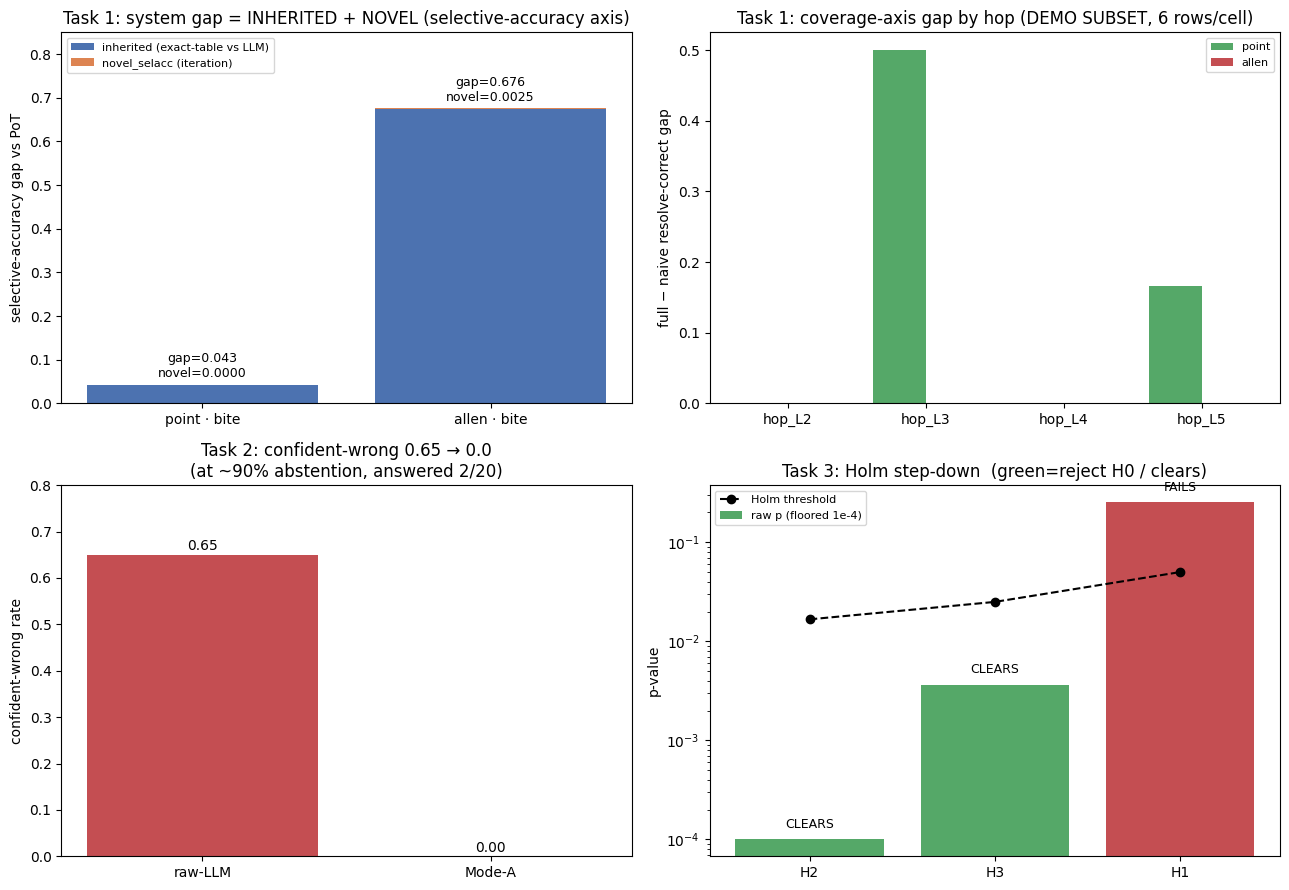


LLM spend: $0.00  |  discrepancies: 4 (the 4 coverage-axis subset checks)


In [12]:
decomp = eval_out["metadata"]["decomposition"]
rc     = eval_out["metadata"]["risk_coverage"]
mult   = eval_out["metadata"]["multiplicity"]
ma     = eval_out["metrics_agg"]

def f(x, nd=4):
    return "  n/a" if x is None else f"{x:.{nd}f}"

# ---- Task 1: selective-accuracy decomposition (EXACT, from leaderboard aggregates) ----
print("="*78)
print("TASK 1  Selective-accuracy decomposition  (system_gap = inherited + novel_selacc)")
print("="*78)
print(f"{'algebra':7} {'pool':14} {'sys_gap':>9} {'inherited':>10} {'novel_sel':>10} {'resid':>8}")
for alg in ["point", "allen"]:
    for pool in ["bite_bearing", "all_comparison"]:
        p = decomp[alg]["selective_accuracy_axis"][pool]
        print(f"{alg:7} {pool:14} {f(p['system_gap']):>9} "
              f"{f(p['inherited_component']):>10} {f(p['novel_selacc_component']):>10} "
              f"{f(p['additivity_residual']):>8}")

# ---- Task 1: coverage-axis gaps (recomputed on the demo subset) ----
print("\n" + "="*78)
print("TASK 1  Coverage-axis full-minus-naive resolve-correct gap by hop  (DEMO SUBSET)")
print("="*78)
print(f"{'algebra':7} {'cell':10} {'n':>4} {'full_rc':>8} {'naive_rc':>9} {'gap':>8}")
for alg in ["point", "allen"]:
    for row in decomp[alg]["coverage_axis"]["novel_coverage_gap_by_hop"]:
        print(f"{alg:7} {row['cell']:10} {row['n']:>4} {f(row['full_resolve_correct'],3):>8} "
              f"{f(row['naive_resolve_correct'],3):>9} {f(row['gap'],3):>8}")

# ---- Task 2: risk-coverage operating points ----
print("\n" + "="*78)
print("TASK 2  Risk-coverage operating points (real text, n=20)")
print("="*78)
op = rc["modeA_operating_point"]; raw = rc["raw_operating_point"]
print(f"Mode-A : coverage={f(op['coverage'],2)}  selective_acc={f(op['selective_accuracy'],2)}  "
      f"confident_wrong={f(op['confident_wrong'],2)}  abstention={f(op['abstention_rate'],2)}")
print(f"raw-LLM: coverage={f(raw['coverage'],2)}  accuracy={f(raw['accuracy'],2)}  "
      f"confident_wrong={f(raw['confident_wrong'],2)}")
print("AUC risk-coverage (n=20, underpowered):",
      {k: round(v,3) for k, v in rc["auc_risk_coverage"].items()})

# ---- Task 3: Holm-Bonferroni multiplicity ----
print("\n" + "="*78)
print("TASK 3  Holm-Bonferroni confirmatory family")
print("="*78)
for row in mult["confirmatory_table"]:
    rp = row["raw_p"]; rp_s = rp if isinstance(rp, str) else f"{rp:.4f}"
    print(f"  {row['hypothesis']}: raw_p={rp_s:>10}  reject={str(row['reject']):>5}  "
          f"gateway={str(row['is_gateway']):>5}")
print("\nGatekeeping:", mult["gatekeeping_logic"])

# ----------------------------------- PLOTS ----------------------------------- #
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Stacked decomposition: inherited + novel = system_gap (bite pool)
ax = axes[0, 0]
labels = ["point · bite", "allen · bite"]
inh = [decomp["point"]["selective_accuracy_axis"]["bite_bearing"]["inherited_component"],
       decomp["allen"]["selective_accuracy_axis"]["bite_bearing"]["inherited_component"]]
nov = [decomp["point"]["selective_accuracy_axis"]["bite_bearing"]["novel_selacc_component"],
       decomp["allen"]["selective_accuracy_axis"]["bite_bearing"]["novel_selacc_component"]]
ax.bar(labels, inh, color="#4C72B0", label="inherited (exact-table vs LLM)")
ax.bar(labels, nov, bottom=inh, color="#DD8452", label="novel_selacc (iteration)")
for i, (a, b) in enumerate(zip(inh, nov)):
    ax.text(i, a + b + 0.01, f"gap={a+b:.3f}\nnovel={b:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("selective-accuracy gap vs PoT")
ax.set_title("Task 1: system gap = INHERITED + NOVEL (selective-accuracy axis)")
ax.set_ylim(0, 0.85); ax.legend(loc="upper left", fontsize=8)

# (2) Coverage-axis gap by hop bin (demo subset)
ax = axes[0, 1]
hops = ["hop_L2_P2", "hop_L3_P2", "hop_L4_P2", "hop_L5_P2"]
xp = np.arange(len(hops)); w = 0.38
for k, (alg, col) in enumerate([("point", "#55A868"), ("allen", "#C44E52")]):
    g = {r["cell"]: r["gap"] for r in decomp[alg]["coverage_axis"]["novel_coverage_gap_by_hop"]}
    ax.bar(xp + (k - 0.5)*w, [g.get(h, 0.0) for h in hops], w, label=alg, color=col)
ax.set_xticks(xp); ax.set_xticklabels([h.replace("_P2", "") for h in hops])
ax.set_ylabel("full − naive resolve-correct gap")
ax.set_title("Task 1: coverage-axis gap by hop (DEMO SUBSET, 6 rows/cell)")
ax.axhline(0, color="k", lw=0.6); ax.legend(fontsize=8)

# (3) Risk-coverage: confident-wrong raw vs Mode-A
ax = axes[1, 0]
ax.bar(["raw-LLM", "Mode-A"], [raw["confident_wrong"], op["confident_wrong"]],
       color=["#C44E52", "#55A868"])
ax.set_ylabel("confident-wrong rate")
ax.set_title(f"Task 2: confident-wrong 0.65 → 0.0\n(at ~{op['abstention_rate']:.0%} abstention, answered "
             f"{int(ma['realtext_n_modeA_answered'])}/{int(ma['realtext_n_total'])})")
ax.set_ylim(0, 0.8)
for i, v in enumerate([raw["confident_wrong"], op["confident_wrong"]]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

# (4) Holm-Bonferroni: raw p vs threshold
ax = axes[1, 1]
hc = mult["holm_chain"]
items = [("H2", "H2_realtext"), ("H3", "H3_channel"), ("H1", "H1_realtext")]
names = [n for n, _ in items]
ps  = [max(hc[k]["raw_p"], 1e-4) for _, k in items]   # floor for visibility
thr = [hc[k]["holm_threshold"] for _, k in items]
rej = [hc[k]["reject_at_0.05"] for _, k in items]
cols = ["#55A868" if r else "#C44E52" for r in rej]
ax.bar(names, ps, color=cols, label="raw p (floored 1e-4)")
ax.plot(names, thr, "k--o", label="Holm threshold")
ax.set_ylabel("p-value"); ax.set_yscale("log")
ax.set_title("Task 3: Holm step-down  (green=reject H0 / clears)")
for i, (p, r) in enumerate(zip(ps, rej)):
    ax.text(i, p*1.3, "CLEARS" if r else "FAILS", ha="center", fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("\nLLM spend: $%.2f  |  discrepancies: %d (the 4 coverage-axis subset checks)"
      % (ma["llm_spend_usd"], int(ma["n_discrepancies"])))